# Compare $\Delta \Phi$ integrand and integral: `Classes_ver2` (ODE) vs `Classes_ver3` (vectorized)

This notebook checks that the vectorized implementation in `modules/Classes_ver3.py` matches the original ODE-based implementation in `modules/Classes_ver2.py` for both the integrand and the integrated phase Δφ.

In [ ]:
import sys, os

sys.path.insert(0, "../")

import numpy as np
import matplotlib.pyplot as plt
from modules.Classes_ver2 import Precessing as P2
from modules.Classes_ver3 import Precessing as P3
from modules.default_params_ver2 import *
from modules.functions_ver2 import set_to_location
from scipy.integrate import cumulative_trapezoid

In [56]:
# Build a common parameter set
params = RP_params_1.copy()
(params,) = set_to_location(loc_params["Taman"]["edgeon"], params)

# Fix angles to avoid singularities; use moderate precession
# params.update(
#     {
#         "theta_S": np.pi / 3,
#         "phi_S": np.pi / 4,
#         "theta_J": np.pi / 6,
#         "phi_J": np.pi / 3,
#         "theta_tilde": 6.0,
#         "omega_tilde": 2.5,
#         "gamma_P": 0.0,
#     }
# )

p2 = P2(params)
p3 = P3(params)

# Frequency array
f_min = 20.0
f_cut = p2.f_cut()
f_arr = np.linspace(f_min, f_cut * 0.9, 2000)

In [57]:
# Compute integrands
%time integrand2 = np.array([p2.integrand_delta_phi(0, fi) for fi in f_arr])
%time integrand3 = p3._integrand_delta_phi_vec(f_arr)

# Integrate
%time phase2 = np.atleast_1d(p2.phase_delta_phi(f_arr))
%time phase3 = cumulative_trapezoid(integrand3, f_arr, initial=0.0)

CPU times: user 70.1 ms, sys: 3.78 ms, total: 73.9 ms
Wall time: 80.2 ms
CPU times: user 906 µs, sys: 252 µs, total: 1.16 ms
Wall time: 1.37 ms
CPU times: user 7.72 ms, sys: 97 µs, total: 7.82 ms
Wall time: 8.07 ms
CPU times: user 71 µs, sys: 1e+03 ns, total: 72 µs
Wall time: 74.1 µs


Integrand L2 norm: 0.0
Phase L2 norm: 1.5261872026161992e-05


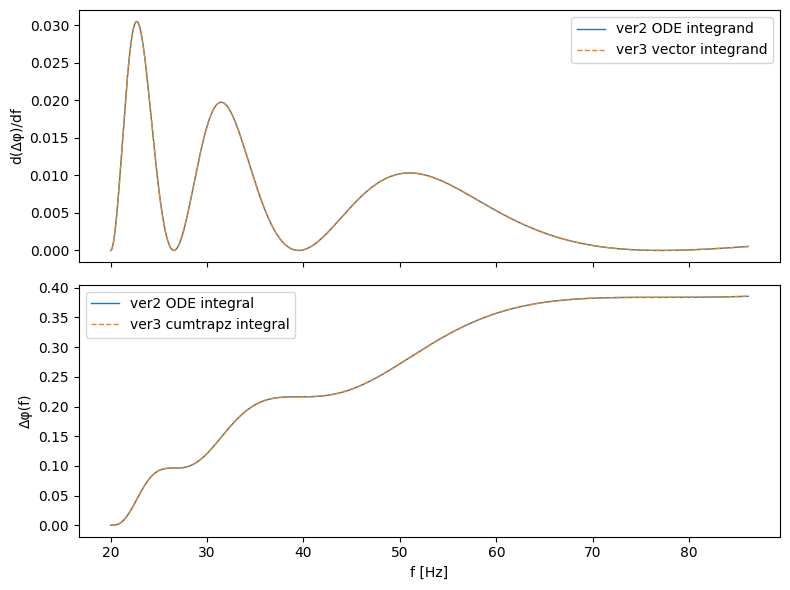

In [58]:
print("Integrand L2 norm:", np.linalg.norm(integrand2 - integrand3))
print("Phase L2 norm:", np.linalg.norm(phase2 - phase3))

fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(f_arr, integrand2, label="ver2 ODE integrand", lw=1)
ax[0].plot(f_arr, integrand3, label="ver3 vector integrand", lw=1, ls="--")
ax[0].set_ylabel("d(Δφ)/df")
ax[0].legend()

ax[1].plot(f_arr, phase2, label="ver2 ODE integral", lw=1)
ax[1].plot(f_arr, phase3, label="ver3 cumtrapz integral", lw=1, ls="--")
ax[1].set_xlabel("f [Hz]")
ax[1].set_ylabel("Δφ(f)")
ax[1].legend()
plt.tight_layout()